In [1]:
import pandas as pd

# Load the full dataset
df = pd.read_csv("finalsortedrows.csv")  # replace with your file path

df.tail(3)

,carbohydrates_(g),cholesterol_(mg),energy_(kcal),fat_(g),fiber_(g),minerals_(mg),proteins_(g),salt/sodium_(mg),saturated-fat_(g),vitamins_(mg),nova_group
149997,27.0,5.0,375.0,15.0,2.2,300.0,7.0,900.0,6.0,1.5,4.0
149998,26.0,0.0,150.0,0.5,1.0,10.0,3.0,5.0,0.1,0.1,3.0
149999,27.0,5.0,375.0,15.0,2.2,300.0,7.0,900.0,6.0,1.5,4.0


In [2]:
df['energy_(kcal)'] = df['energy_(kcal)']/4.186

In [3]:
df.shape

(150000, 11)

In [4]:
from sklearn.ensemble import RandomForestRegressor

# Train model
rf = RandomForestRegressor()
rf.fit(df.drop('nova_group', axis=1), df['nova_group'])

# Feature importance
importances = pd.Series(rf.feature_importances_, index=df.drop('nova_group', axis=1).columns)
print(importances.sort_values(ascending=False))

saturated-fat_(g)    0.229718
salt/sodium_(mg)     0.188498
energy_(kcal)        0.134414
carbohydrates_(g)    0.132594
fiber_(g)            0.103225
proteins_(g)         0.077537
minerals_(mg)        0.067420
fat_(g)              0.032760
vitamins_(mg)        0.028507
cholesterol_(mg)     0.005327
dtype: float64


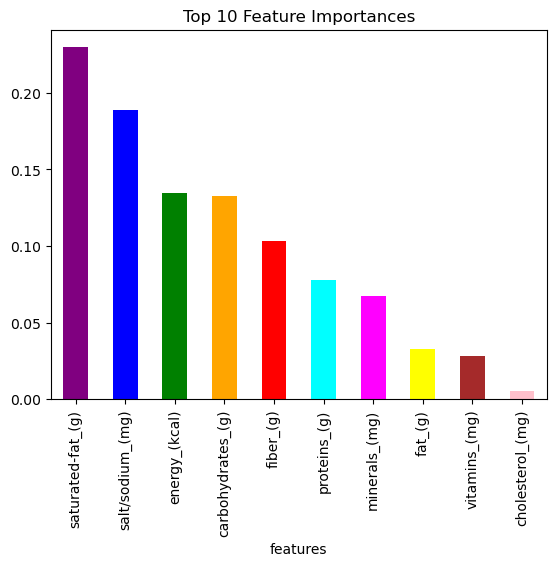

In [5]:
# Define a list of colors for each bar
import matplotlib.pyplot as plt
colors = ['purple', 'blue', 'green', 'orange', 'red', 'cyan', 'magenta', 'yellow', 'brown', 'pink']

# Plot with different colors for each bar
importances.sort_values(ascending=False).head(10).plot(kind='bar',  color=colors)

plt.title('Top 10 Feature Importances')
plt.xlabel('features')
plt.savefig('feature_importance_pie', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
df.tail(3)

,carbohydrates_(g),cholesterol_(mg),energy_(kcal),fat_(g),fiber_(g),minerals_(mg),proteins_(g),salt/sodium_(mg),saturated-fat_(g),vitamins_(mg),nova_group
149997,27.0,5.0,89.584329,15.0,2.2,300.0,7.0,900.0,6.0,1.5,4.0
149998,26.0,0.0,35.833731,0.5,1.0,10.0,3.0,5.0,0.1,0.1,3.0
149999,27.0,5.0,89.584329,15.0,2.2,300.0,7.0,900.0,6.0,1.5,4.0


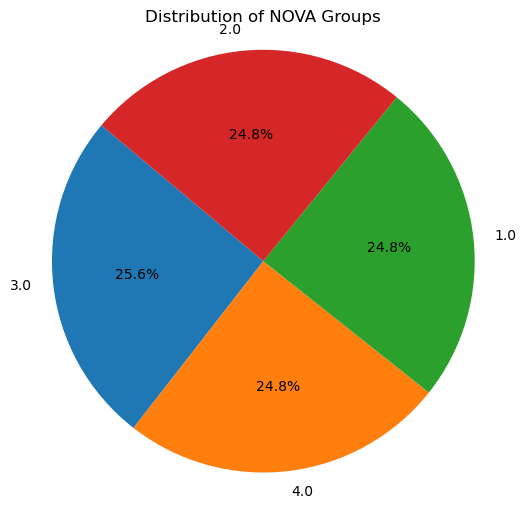

In [7]:
nova_counts = df['nova_group'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(nova_counts, labels=nova_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of NOVA Groups')
plt.axis('equal')  # Ensures the pie chart is circular
plt.savefig('class_distribution.jpg', format= 'jpg', dpi = 300 )
plt.show()

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Step 1: Extract last 500 rows (fixed part of training)
fixed_train = df.tail(500)

# Step 2: Get the remaining 149500 rows
remaining = df.iloc[:-500]

# Step 3: Split the remaining into train and test
X = remaining.drop(columns='nova_group')  # Replace with your actual target column
y = remaining['nova_group']

X_temp_train, X_test, y_temp_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # optional: stratify if classification
)

# Step 4: Extract X and y from fixed 500 rows
X_fixed = fixed_train.drop(columns='nova_group')
y_fixed = fixed_train['nova_group']

# Step 5: Combine random training split + fixed last 500 rows
X_train = pd.concat([X_temp_train, X_fixed], ignore_index=True)
y_train = pd.concat([y_temp_train, y_fixed], ignore_index=True)

X_train.columns

Index(['carbohydrates_(g)', 'cholesterol_(mg)', 'energy_(kcal)', 'fat_(g)',
       'fiber_(g)', 'minerals_(mg)', 'proteins_(g)', 'salt/sodium_(mg)',
       'saturated-fat_(g)', 'vitamins_(mg)'],
      dtype='object')

In [9]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=50, random_state=42)

In [10]:
y_pred = model.predict(X_test)

In [11]:
model.score(X_test,y_test)

0.8394648829431438

In [12]:
len(y_test)

29900

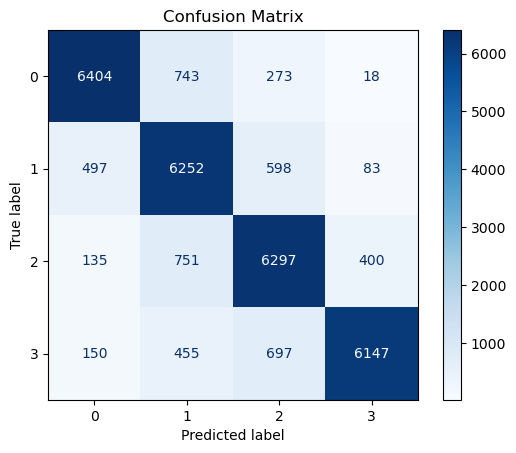

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Step 1: Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Step 2: Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.savefig("Confustion Matrix.jpg", format='jpg', dpi=300)
plt.show()
            

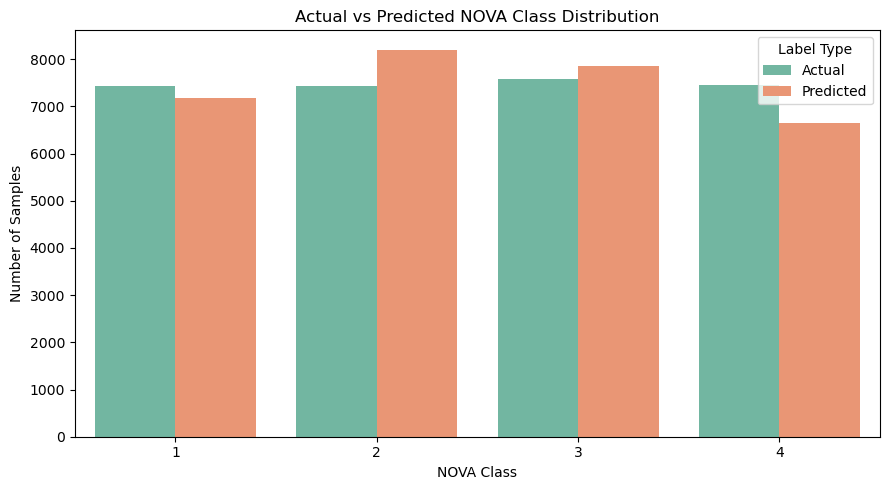

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Count occurrences
actual_counts = Counter(y_test)
pred_counts = Counter(y_pred)

# Get all class labels (sorted)
labels = [1, 2, 3, 4]  # explicitly define all 4 NOVA classes


# Create a DataFrame for plotting
df_plot = pd.DataFrame({
    'Class': labels,
    'Actual': [actual_counts.get(label, 1) for label in labels],
    'Predicted': [pred_counts.get(label, 1) for label in labels]
})

# Melt the DataFrame to long format for Seaborn
df_melted = pd.melt(df_plot, id_vars='Class', value_vars=['Actual', 'Predicted'],
                    var_name='Type', value_name='Count')

# Plotting
plt.figure(figsize=(9, 5))
sns.barplot(x='Class', y='Count', hue='Type', data=df_melted, palette='Set2')
plt.title('Actual vs Predicted NOVA Class Distribution')
plt.xlabel('NOVA Class')
plt.ylabel('Number of Samples')
plt.legend(title='Label Type')
plt.tight_layout()
plt.savefig('bargraph_classification.jpg', format = 'jpg', dpi= 300)
plt.show()


In [15]:
# Normalized confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_pred, normalize='true'))
disp.plot(cmap='Blues')
plt.title("Normalized Confusion Matrix")
plt.show()


NameError: name 'y_true' is not defined

In [16]:
# Save compressed model
import joblib
joblib.dump(model, "random_forest_model.pkl", compress=3)
print("Model saved to 'random_forest_model.pkl'")

Model saved to 'random_forest_model.pkl'
